# DEEP LEARNING MILESTONE 1


# Cell 1 — Mount Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Cell 2 — Dataset path

In [2]:
dataset_path = '/content/drive/MyDrive/DEEPLRL_Data'

# Cell 3 — Imports


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Cell 4


In [4]:
# More aggressive augmentation now that you have more images
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],   # simulate lighting variation
    shear_range=0.1,               # slight perspective shift
    fill_mode='nearest'
)

# Validation: rescale only — never augment
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Cell 5


In [5]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

validation_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"Training samples  : {train_data.samples}")
print(f"Validation samples: {validation_data.samples}")
print(f"Class indices     : {train_data.class_indices}")

Found 379 images belonging to 6 classes.
Found 93 images belonging to 6 classes.
Training samples  : 379
Validation samples: 93
Class indices     : {'collab': 0, 'hdmi ': 1, 'rj45': 2, 'sata': 3, 'usba': 4, 'vga': 5}


# Cell 6


In [6]:
labels = train_data.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)
print("Class indices:", train_data.class_indices)

Class weights: {0: np.float64(1.1147058823529412), 1: np.float64(1.0676056338028168), 2: np.float64(0.8063829787234043), 3: np.float64(0.9358024691358025), 4: np.float64(1.166153846153846)}
Class indices: {'collab': 0, 'hdmi ': 1, 'rj45': 2, 'sata': 3, 'usba': 4, 'vga': 5}


# Cell 7


In [7]:
from tensorflow.keras.layers import SeparableConv2D

inputs = tf.keras.Input(shape=(128, 128, 3))

# Block 1
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 2
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 3 — SeparableConv2D is lighter and regularizes better
x = SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 4 — added for more capacity now that dataset is larger
x = SeparableConv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)

# Head — L2 regularization discourages large weights
x = layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(train_data.num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 32, 32, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 16, 16, 256)    │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,846 (640.02 KB)

 Trainable params: 162,886 (636.27 KB)

 Non-trainable params: 960 (3.75 KB)

# Cell 8

In [8]:
optimizer = Adam(
    learning_rate=1e-4,   # lower LR = smoother convergence, less overfit
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Cell 9

In [9]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,           # more patience now that LR is lower
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Cell 10

In [10]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,           # more patience now that LR is lower
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Cell 11 — Train


In [11]:
history = model.fit(
    train_data,
    epochs=50,               # EarlyStopping handles this
    validation_data=validation_data,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.2481 - loss: 1.7508 
Epoch 1: val_accuracy improved from None to 0.26882, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 294s 24s/step - accuracy: 0.3351 - loss: 1.6842 - val_accuracy: 0.2688 - val_loss: 1.8307 - learning_rate: 1.0000e-04
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4828 - loss: 1.5127
Epoch 2: val_accuracy did not improve from 0.26882
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5277 - loss: 1.4657 - val_accuracy: 0.2473 - val_loss: 1.8260 - learning_rate: 1.0000e-04
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5763 - loss: 1.3424
Epoch 3: val_accuracy improved from 0.26882 to 0.27957, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.5778 - loss: 1.3142 - val_accuracy: 0.2796 - val_loss: 1.8204 - learning_rate:

# Cell 12 — Evaluate



In [13]:
loss, accuracy = model.evaluate(validation_data)
print(f'\nValidation Accuracy: {accuracy:.4f}')
print(f'Validation Loss    : {loss:.4f}')

# Detailed per-class report
validation_data.reset()
y_pred_probs = model.predict(validation_data)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_data.classes

# Get all class labels from training data indices
all_class_labels = list(train_data.class_indices.keys())

# Determine unique labels present in y_true
unique_labels_in_y_true = np.unique(y_true)

# Filter class_labels to only include those present in y_true
# And ensure the order matches the unique_labels_in_y_true indices
filtered_class_labels = [all_class_labels[i] for i in unique_labels_in_y_true]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=unique_labels_in_y_true, target_names=filtered_class_labels))

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3441 - loss: 1.8080

Validation Accuracy: 0.3441
Validation Loss    : 1.8080
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step

Classification Report:
              precision    recall  f1-score   support

       hdmi        0.00      0.00      0.00        17
        rj45       0.30      1.00      0.47        17
        sata       0.41      0.65      0.50        23
        usba       0.00      0.00      0.00        20
         vga       0.00      0.00      0.00        16

    accuracy                           0.34        93
   macro avg       0.14      0.33      0.19        93
weighted avg       0.16      0.34      0.21        93



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Cell 13 — Plot accuracy

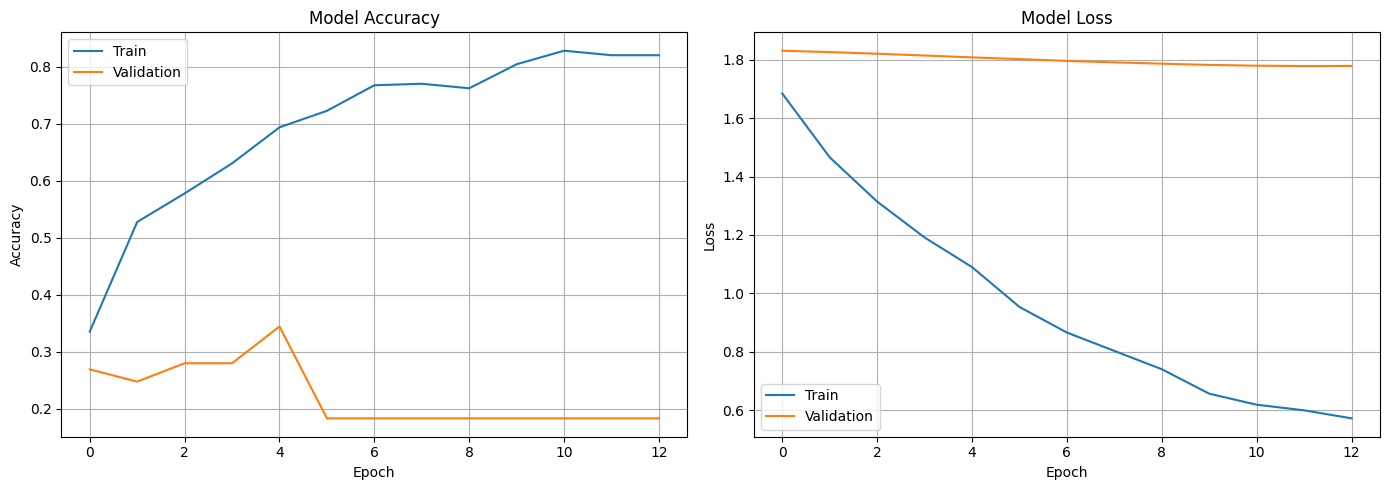

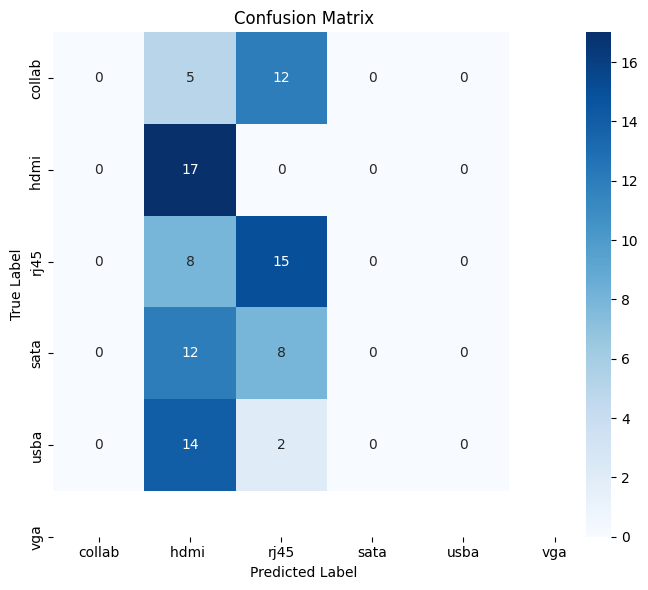

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Cell 14 — Save model

In [15]:
#model.save("cnn_classifier.h5")

# Cell 15 — Download mode

In [16]:
#from google.colab import files
#files.download("cnn_classifier.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cell 16 — Test single image in Colab

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = image.load_img(filename, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

class_labels = list(train_data.class_indices.keys())

plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {class_labels[predicted_class]} ({confidence:.1f}%)")
plt.show()

In [ ]:


# Upload image from local computer
uploaded = files.upload()

# Get the uploaded filename
filename = list(uploaded.keys())[0]

# Load and resize image
img = image.load_img(filename, target_size=(128,128))

# Convert image to array
img_array = image.img_to_array(img)

# Normalize pixel values
img_array = img_array / 255.0

# Expand dimensions to match model input
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)

# Get predicted class index
predicted_class = np.argmax(prediction)

# Get class label names
class_labels = list(train_data.class_indices.keys())



In [ ]:
# Display image
plt.imshow(img)
plt.axis('off')
plt.title("Predicted Class: " + class_labels[predicted_class])
plt.show()

# Streamlit Save

In [ ]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# ── Page config ──────────────────────────────────────────────
st.set_page_config(
    page_title="Connector Classifier",
    page_icon="🔌",
    layout="centered"
)

st.title("🔌 Network Connector Classifier")
st.write("Upload an image to identify the connector type: **SATA, VGA, USB-A, HDMI, or RJ45**")

# ── Load model (cached so it only loads once) ────────────────
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("cnn_classifier.keras")

model = load_model()

CLASS_LABELS = ['hdmi', 'rj45', 'sata', 'usba', 'vga']  # alphabetical — matches flow_from_directory

# ── Upload ───────────────────────────────────────────────────
uploaded_file = st.file_uploader(
    "Choose an image", type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    img = Image.open(uploaded_file).convert("RGB")
    st.image(img, caption="Uploaded image", use_column_width=True)

    # Preprocess
    img_resized = img.resize((128, 128))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    with st.spinner("Classifying..."):
        prediction = model.predict(img_array)[0]

    predicted_idx = np.argmax(prediction)
    predicted_label = CLASS_LABELS[predicted_idx]
    confidence = prediction[predicted_idx] * 100

    # ── Results ──────────────────────────────────────────────
    st.markdown("---")
    col1, col2 = st.columns(2)
    with col1:
        st.metric("Predicted Connector", predicted_label.upper())
    with col2:
        st.metric("Confidence", f"{confidence:.1f}%")

    # Confidence bar chart for all classes
    st.markdown("#### Confidence per class")
    for label, score in zip(CLASS_LABELS, prediction):
        st.progress(
            float(score),
            text=f"{label.upper()}: {score*100:.1f}%"
        )

    if confidence < 60:
        st.warning(
            "⚠️ Low confidence — the model is unsure. "
            "This may be due to limited training data (especially HDMI)."
        )